# 3. Análisis exploratorio de datos

**Issue:** [#3 Análisis exploratorio de datos (EDA)](https://github.com/velascocafe23/telco-churn-mlops/issues/3)

Este notebook caracteriza el conjunto de datos en tres niveles: cada atributo por
separado, su relación con el objetivo, y las relaciones entre varios atributos.

El análisis no es un fin en sí mismo. Debe producir tres salidas concretas que se usan
en etapas posteriores del proyecto:

1. Una **regla heurística** que sirva como referencia mínima de desempeño.
2. Las **reglas de validación de datos** que implementará el pipeline de atributos.
3. Las **transformaciones candidatas** para la ingeniería de atributos.

## 3.1 Configuración

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.metrics import classification_report, confusion_matrix

INTERMEDIATE_FILE = Path("../../data/02_intermediate/telco_customer_churn.parquet")

IDENTIFICADOR = "customerID"
OBJETIVO = "Churn"
CLASE_POSITIVA = "Yes"

COLUMNAS_NUMERICAS = ["tenure", "MonthlyCharges", "TotalCharges"]

ALFA = 0.05
UMBRAL_ASOCIACION_MODERADA = 0.2
UMBRAL_CORRELACION_ALTA = 0.8

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100

datos = pd.read_parquet(INTERMEDIATE_FILE)

COLUMNAS_CATEGORICAS = [
    columna for columna in datos.select_dtypes(include="category").columns if columna != OBJETIVO
]

print(f"Registros:    {len(datos)}")
print(f"Numéricas:    {len(COLUMNAS_NUMERICAS)}")
print(f"Categóricas:  {len(COLUMNAS_CATEGORICAS)}")

Registros:    7043
Numéricas:    3
Categóricas:  16


## 3.2 Análisis univariable

### 3.2.1 El atributo objetivo

In [2]:
conteo_objetivo = datos[OBJETIVO].value_counts()
proporcion_objetivo = datos[OBJETIVO].value_counts(normalize=True)
tasa_base = proporcion_objetivo[CLASE_POSITIVA]

print(conteo_objetivo.to_string())
print()
print(f"Tasa de cancelación: {tasa_base:.2%}")
print(f"Razón de desbalance: {conteo_objetivo['No'] / conteo_objetivo['Yes']:.2f} a 1")

Churn
No     5174
Yes    1869

Tasa de cancelación: 26.54%
Razón de desbalance: 2.77 a 1


El desbalance es moderado, no severo. No justifica técnicas de remuestreo agresivas,
pero sí obliga a tres decisiones: estratificar la partición, descartar la exactitud como
métrica principal, y considerar la ponderación de clases durante el entrenamiento.

La tasa base es además el punto de referencia para interpretar todo lo que sigue: un
segmento solo es informativo si su tasa de cancelación se aparta de este valor.

### 3.2.2 Atributos numéricos

In [3]:
descriptivos = datos[COLUMNAS_NUMERICAS].describe().T
descriptivos["IQR"] = descriptivos["75%"] - descriptivos["25%"]
descriptivos["asimetria"] = datos[COLUMNAS_NUMERICAS].skew()
descriptivos["curtosis"] = datos[COLUMNAS_NUMERICAS].kurtosis()
descriptivos["nulos"] = datos[COLUMNAS_NUMERICAS].isna().sum()

descriptivos.round(2)

,count,mean,std,min,25%,50%,75%,max,IQR,asimetria,curtosis,nulos
tenure,7043.0,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0,46.0,0.24,-1.39,0
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75,54.35,-0.22,-1.26,0
TotalCharges,7032.0,2283.300441,2266.771362,18.8,401.45,1397.475,3794.7375,8684.8,3393.2875,0.96,-0.23,11


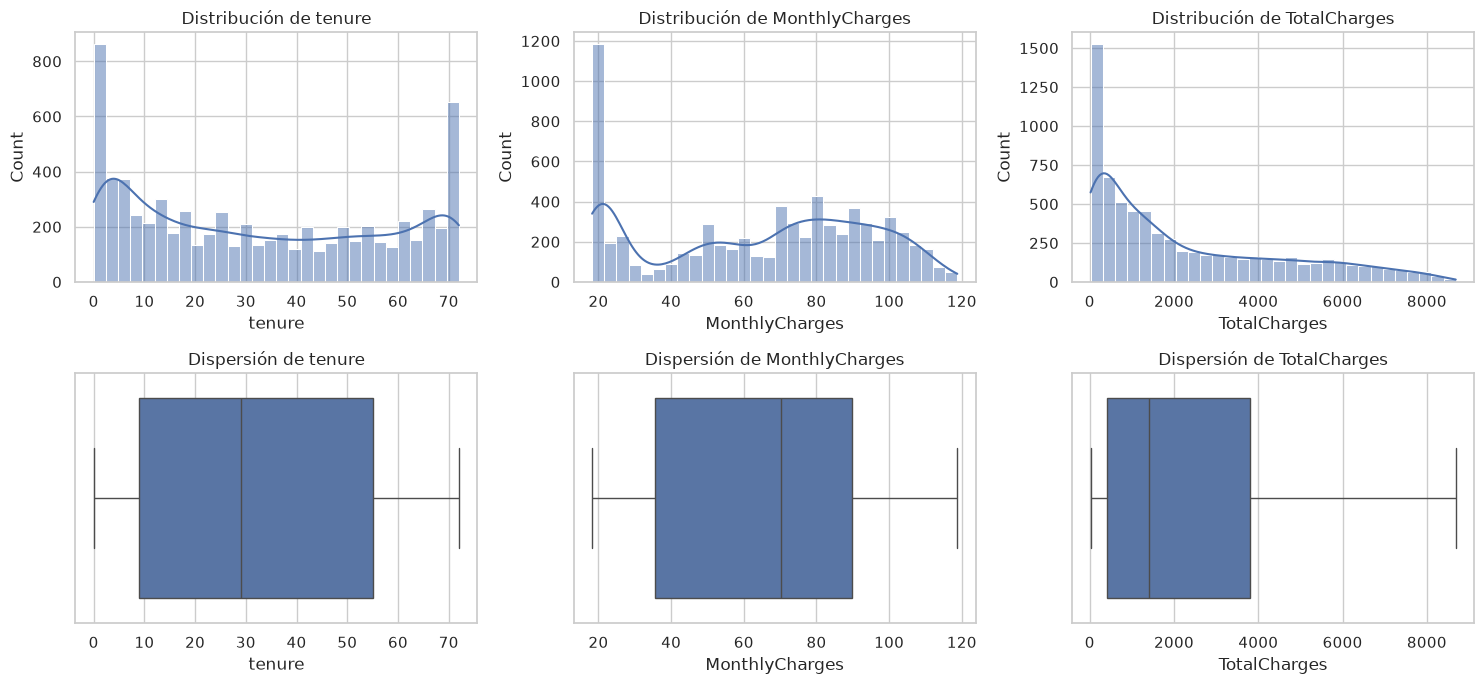

In [4]:
figura, ejes = plt.subplots(2, 3, figsize=(15, 7))

for indice, columna in enumerate(COLUMNAS_NUMERICAS):
    sns.histplot(data=datos, x=columna, bins=30, ax=ejes[0, indice], kde=True)
    ejes[0, indice].set_title(f"Distribución de {columna}")
    sns.boxplot(data=datos, x=columna, ax=ejes[1, indice])
    ejes[1, indice].set_title(f"Dispersión de {columna}")

figura.tight_layout()
plt.show()

In [5]:
for columna in COLUMNAS_NUMERICAS:
    serie = datos[columna].dropna()
    q1, q3 = serie.quantile([0.25, 0.75])
    rango = q3 - q1
    limite_inferior = q1 - 1.5 * rango
    limite_superior = q3 + 1.5 * rango
    atipicos = ((serie < limite_inferior) | (serie > limite_superior)).sum()
    print(f"{columna:16s} atípicos por IQR: {atipicos:4d}  ({atipicos / len(serie):.2%})")

tenure           atípicos por IQR:    0  (0.00%)
MonthlyCharges   atípicos por IQR:    0  (0.00%)
TotalCharges     atípicos por IQR:    0  (0.00%)


Las tres distribuciones son informativas:

- **`tenure`** es marcadamente bimodal. Hay una concentración de clientes muy nuevos y
  otra de clientes muy antiguos, con un valle en el medio. Esa forma sugiere dos
  poblaciones distintas y es el primer argumento a favor de discretizar la antigüedad
  en tramos en lugar de tratarla como una magnitud continua.
- **`MonthlyCharges`** también es bimodal, reflejo de la separación entre clientes de
  solo telefonía y clientes con internet.
- **`TotalCharges`** tiene fuerte asimetría positiva, consecuencia esperable de ser un
  acumulado: crece con la antigüedad.

Ausencia de valores atípicos por el criterio del rango intercuartílico. Los valores
extremos de `TotalCharges` son clientes antiguos legítimos, no errores de captura, de
modo que **no corresponde eliminarlos ni recortarlos**.

### 3.2.3 Atributos categóricos

In [6]:
resumen_categoricas = []
for columna in COLUMNAS_CATEGORICAS:
    frecuencias = datos[columna].value_counts(normalize=True)
    resumen_categoricas.append(
        {
            "atributo": columna,
            "categorias": datos[columna].nunique(),
            "mas_frecuente": frecuencias.index[0],
            "pct_mas_frecuente": round(frecuencias.iloc[0] * 100, 1),
            "menos_frecuente": frecuencias.index[-1],
            "pct_menos_frecuente": round(frecuencias.iloc[-1] * 100, 1),
        }
    )

pd.DataFrame(resumen_categoricas)

,atributo,categorias,mas_frecuente,pct_mas_frecuente,menos_frecuente,pct_menos_frecuente
0,gender,2,Male,50.5,Female,49.5
1,SeniorCitizen,2,No,83.8,Yes,16.2
2,Partner,2,No,51.7,Yes,48.3
3,Dependents,2,No,70.0,Yes,30.0
4,PhoneService,2,Yes,90.3,No,9.7
5,MultipleLines,3,No,48.1,No phone service,9.7
6,InternetService,3,Fiber optic,44.0,No,21.7
7,OnlineSecurity,3,No,49.7,No internet service,21.7
8,OnlineBackup,3,No,43.8,No internet service,21.7
9,DeviceProtection,3,No,43.9,No internet service,21.7


Ninguna categoría queda por debajo de un umbral que haga peligrar la estimación, de modo
que no hay que agrupar categorías raras. El atributo con mayor cardinalidad tiene cuatro
niveles, lo que mantiene acotada la dimensionalidad tras el *encoding*.

## 3.3 Análisis bivariable

### 3.3.1 Atributos categóricos frente al objetivo

Para cada atributo se mide la fuerza de asociación con la cancelación mediante la V de
Cramér, que normaliza el estadístico chi cuadrado y permite comparar atributos con
distinto número de categorías.

In [7]:
def v_de_cramer(serie_a: pd.Series, serie_b: pd.Series) -> tuple[float, float]:
    """Calcula la V de Cramer y el valor p entre dos variables categoricas."""
    tabla = pd.crosstab(serie_a, serie_b)
    chi2, valor_p, _, _ = chi2_contingency(tabla)
    n = tabla.to_numpy().sum()
    dimension_minima = min(tabla.shape) - 1
    return float(np.sqrt(chi2 / (n * dimension_minima))), float(valor_p)


asociaciones = []
for columna in COLUMNAS_CATEGORICAS:
    fuerza, valor_p = v_de_cramer(datos[columna], datos[OBJETIVO])
    asociaciones.append(
        {
            "atributo": columna,
            "v_cramer": round(fuerza, 4),
            "valor_p": valor_p,
            "significativo": valor_p < ALFA,
        }
    )

tabla_asociaciones = pd.DataFrame(asociaciones).sort_values("v_cramer", ascending=False)
tabla_asociaciones.reset_index(drop=True)

,atributo,v_cramer,valor_p,significativo
0,Contract,0.4101,5.863038e-258,True
1,OnlineSecurity,0.3474,2.661150e-185,True
2,TechSupport,0.3429,1.443084e-180,True
3,InternetService,0.3225,9.571788e-160,True
4,PaymentMethod,0.3034,3.682355e-140,True
5,OnlineBackup,0.2923,2.079759e-131,True
6,DeviceProtection,0.2816,5.505219e-122,True
7,StreamingMovies,0.2310,2.667757e-82,True
8,StreamingTV,0.2305,5.528994e-82,True
9,PaperlessBilling,0.1915,4.073355e-58,True


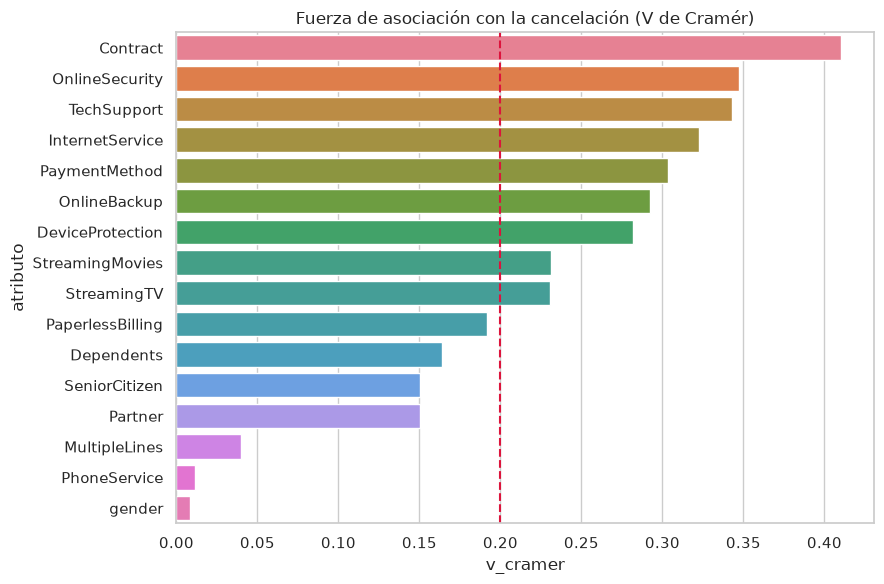

In [8]:
figura, eje = plt.subplots(figsize=(9, 6))
sns.barplot(
    data=tabla_asociaciones,
    y="atributo",
    x="v_cramer",
    hue="atributo",
    legend=False,
    ax=eje,
)
eje.axvline(UMBRAL_ASOCIACION_MODERADA, color="crimson", linestyle="--")
eje.set_title("Fuerza de asociación con la cancelación (V de Cramér)")
figura.tight_layout()
plt.show()

In [9]:
atributos_relevantes = tabla_asociaciones.loc[
    tabla_asociaciones["v_cramer"] >= UMBRAL_ASOCIACION_MODERADA, "atributo"
].tolist()

for columna in atributos_relevantes:
    tabla = pd.crosstab(datos[columna], datos[OBJETIVO], normalize="index")
    print(f"\nTasa de cancelación por {columna}")
    print((tabla[CLASE_POSITIVA] * 100).round(1).to_string())


Tasa de cancelación por Contract
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8

Tasa de cancelación por OnlineSecurity
OnlineSecurity
No                     41.8
No internet service     7.4
Yes                    14.6

Tasa de cancelación por TechSupport
TechSupport
No                     41.6
No internet service     7.4
Yes                    15.2

Tasa de cancelación por InternetService
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4

Tasa de cancelación por PaymentMethod
PaymentMethod
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Electronic check             45.3
Mailed check                 19.1

Tasa de cancelación por OnlineBackup
OnlineBackup
No                     39.9
No internet service     7.4
Yes                    21.5

Tasa de cancelación por DeviceProtection
DeviceProtection
No                     39.1
No internet service     7.4
Yes                    22.5

Tasa de cancelación por Streami

### 3.3.2 Atributos numéricos frente al objetivo

Las distribuciones no son normales, así que la comparación entre grupos se hace con la
prueba de Mann-Whitney, que no asume normalidad.

In [10]:
comparaciones = []
for columna in COLUMNAS_NUMERICAS:
    grupo_positivo = datos.loc[datos[OBJETIVO] == CLASE_POSITIVA, columna].dropna()
    grupo_negativo = datos.loc[datos[OBJETIVO] != CLASE_POSITIVA, columna].dropna()
    _, valor_p = mannwhitneyu(grupo_positivo, grupo_negativo)
    comparaciones.append(
        {
            "atributo": columna,
            "mediana_cancela": round(grupo_positivo.median(), 2),
            "mediana_permanece": round(grupo_negativo.median(), 2),
            "valor_p": valor_p,
            "significativo": valor_p < ALFA,
        }
    )

pd.DataFrame(comparaciones)

,atributo,mediana_cancela,mediana_permanece,valor_p,significativo
0,tenure,10.00,38.00,2.419636e-208,True
1,MonthlyCharges,79.65,64.43,3.311628e-54,True
2,TotalCharges,703.55,1683.60,1.995985e-84,True


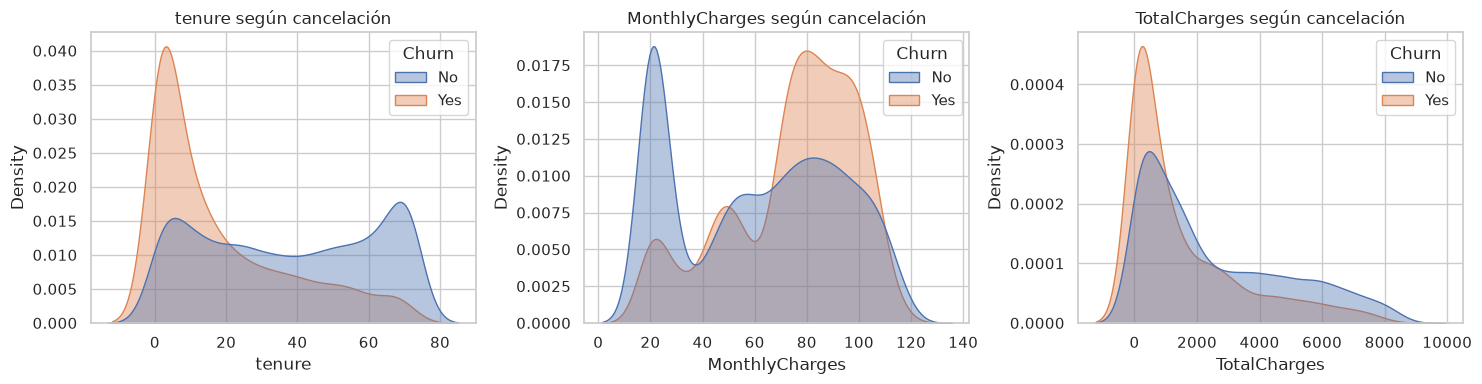

In [11]:
figura, ejes = plt.subplots(1, 3, figsize=(15, 4))

for indice, columna in enumerate(COLUMNAS_NUMERICAS):
    sns.kdeplot(
        data=datos,
        x=columna,
        hue=OBJETIVO,
        common_norm=False,
        fill=True,
        alpha=0.4,
        ax=ejes[indice],
    )
    ejes[indice].set_title(f"{columna} según cancelación")

figura.tight_layout()
plt.show()

La separación más nítida está en `tenure`: la densidad de quienes cancelan se concentra
en los primeros meses, mientras que la de quienes permanecen se desplaza hacia la
derecha. Esta es la señal individual más fuerte del conjunto y es la base de la regla
heurística que se evalúa más adelante.

## 3.4 Análisis multivariable

### 3.4.1 Relaciones entre atributos numéricos

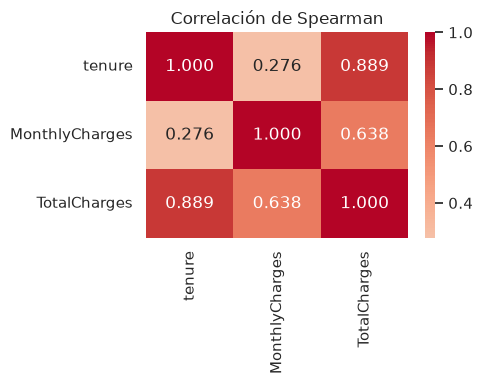

Pares con correlación alta: [('tenure', 'TotalCharges', np.float64(0.889))]


In [12]:
correlaciones = datos[COLUMNAS_NUMERICAS].corr(method="spearman")

figura, eje = plt.subplots(figsize=(5, 4))
sns.heatmap(correlaciones, annot=True, fmt=".3f", cmap="coolwarm", center=0, ax=eje)
eje.set_title("Correlación de Spearman")
figura.tight_layout()
plt.show()

pares_altos = [
    (izquierda, derecha, round(correlaciones.loc[izquierda, derecha], 3))
    for indice, izquierda in enumerate(COLUMNAS_NUMERICAS)
    for derecha in COLUMNAS_NUMERICAS[indice + 1 :]
    if abs(correlaciones.loc[izquierda, derecha]) > UMBRAL_CORRELACION_ALTA
]
print(f"Pares con correlación alta: {pares_altos}")

`TotalCharges` es en buena medida el producto de la antigüedad por el cargo mensual, así
que su correlación con `tenure` es esperable. Esto importa para la interpretación
posterior: en un modelo lineal la colinealidad reparte el peso entre atributos
redundantes y dificulta leer los coeficientes. Los modelos de árboles no sufren este
problema, pero la importancia de atributos sí queda repartida entre las variables
correlacionadas.

### 3.4.2 Interacción entre contrato y antigüedad

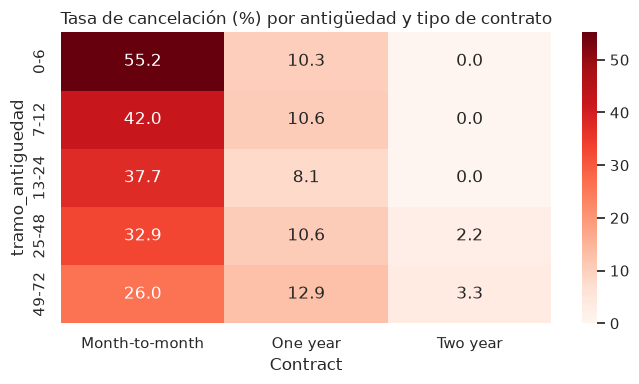

Contract,Month-to-month,One year,Two year
tramo_antiguedad,,,
0-6,55.2,10.3,0.0
7-12,42.0,10.6,0.0
13-24,37.7,8.1,0.0
25-48,32.9,10.6,2.2
49-72,26.0,12.9,3.3


In [13]:
cortes = [0, 6, 12, 24, 48, 72]
etiquetas = ["0-6", "7-12", "13-24", "25-48", "49-72"]
datos_segmentados = datos.assign(
    tramo_antiguedad=pd.cut(datos["tenure"], bins=cortes, labels=etiquetas, include_lowest=True)
)

tabla_interaccion = pd.crosstab(
    datos_segmentados["tramo_antiguedad"],
    datos_segmentados["Contract"],
    values=(datos_segmentados[OBJETIVO] == CLASE_POSITIVA).astype(int),
    aggfunc="mean",
)

figura, eje = plt.subplots(figsize=(7, 4))
sns.heatmap(tabla_interaccion * 100, annot=True, fmt=".1f", cmap="Reds", ax=eje)
eje.set_title("Tasa de cancelación (%) por antigüedad y tipo de contrato")
figura.tight_layout()
plt.show()

(tabla_interaccion * 100).round(1)

La combinación de ambos atributos produce una separación mucho más fuerte que cualquiera
por separado. El cuadrante de contrato mes a mes con antigüedad baja concentra el riesgo,
y el efecto de la antigüedad se atenúa a medida que el contrato es más largo. Esa
interacción es la que justifica tanto la regla heurística como la expectativa de que los
modelos basados en árboles, que capturan interacciones de forma natural, funcionen bien
en este problema.

### 3.4.3 Límite superior de desempeño alcanzable

Si dos clientes tienen exactamente los mismos atributos y distinto desenlace, ningún
modelo puede acertar en ambos. Cuantificar esas contradicciones da una cota superior al
desempeño posible y evita perseguir métricas inalcanzables.

In [14]:
columnas_perfil = [c for c in datos.columns if c not in (IDENTIFICADOR, OBJETIVO)]

perfiles = datos.groupby(columnas_perfil, observed=True)[OBJETIVO].agg(["count", "nunique"])
contradictorios = perfiles[perfiles["nunique"] > 1]

print(f"Perfiles únicos:                  {len(perfiles)}")
print(f"Perfiles con desenlace ambiguo:   {len(contradictorios)}")
print(f"Registros afectados:              {int(contradictorios['count'].sum())}")

Perfiles únicos:                  6992
Perfiles con desenlace ambiguo:   18
Registros afectados:              42


In [15]:
columnas_reducidas = [c for c in columnas_perfil if c not in ("MonthlyCharges", "TotalCharges")]

perfiles_reducidos = datos.groupby(columnas_reducidas, observed=True)[OBJETIVO].agg(
    ["count", "nunique"]
)
ambiguos_reducidos = perfiles_reducidos[perfiles_reducidos["nunique"] > 1]
registros_ambiguos = int(ambiguos_reducidos["count"].sum())

print(f"Perfiles únicos sin los cargos:   {len(perfiles_reducidos)}")
print(f"Perfiles ambiguos:                {len(ambiguos_reducidos)}")
print(
    f"Registros en perfiles ambiguos:   {registros_ambiguos} ({registros_ambiguos / len(datos):.1%})"
)

Perfiles únicos sin los cargos:   6407
Perfiles ambiguos:                103
Registros en perfiles ambiguos:   428 (6.1%)


La lectura de estos dos resultados es distinta y ambas importan.

Con los cargos incluidos hay 6992 perfiles distintos entre 7043 clientes, es decir que
casi cada cliente es unico. Aun asi aparecen 18 perfiles con desenlace contradictorio,
que afectan 42 registros: son exactamente los mismos 42 que el notebook anterior
identifico como clientes con atributos identicos. De aquellos 20 perfiles coincidentes,
18 contienen simultaneamente clientes que cancelaron y clientes que permanecieron.

Al retirar los dos cargos monetarios, que por ser continuos actuan casi como
identificadores, la ambiguedad se revela en su magnitud real: 103 perfiles de servicio y
contrato contienen desenlaces mixtos, y en ellos vive el 6.1% de los registros.

El error irreducible no es ese 6.1% completo, sino la fraccion minoritaria dentro de cada
perfil ambiguo, que es menor. Pero la conclusion se sostiene: **existe un limite al
desempeno alcanzable con esta informacion**. La cancelacion depende de factores que el
conjunto no captura, como la calidad del servicio recibido, las ofertas de la competencia
o motivos personales del cliente. Perseguir una exactitud cercana al 100% en este
problema seria perseguir ruido.


## 3.5 Modelo heurístico

El encuadre del problema planteó que un analista resolvería esto con una regla simple
sobre contrato y antigüedad. El análisis anterior respalda esa intuición, así que se
formaliza y se evalúa la regla:

> Se marca como cliente en riesgo a quien tenga **contrato mes a mes** y **antigüedad
> menor o igual a seis meses**.

Este es el referente que debe superar cualquier modelo de aprendizaje automático.

In [16]:
UMBRAL_ANTIGUEDAD = 6

objetivo_real = (datos[OBJETIVO] == CLASE_POSITIVA).astype(int)
prediccion_heuristica = (
    (datos["Contract"] == "Month-to-month") & (datos["tenure"] <= UMBRAL_ANTIGUEDAD)
).astype(int)

print(classification_report(objetivo_real, prediccion_heuristica, digits=3))
print("Matriz de confusión")
print(confusion_matrix(objetivo_real, prediccion_heuristica))

              precision    recall  f1-score   support

           0      0.807     0.878     0.841      5174
           1      0.552     0.417     0.475      1869

    accuracy                          0.756      7043
   macro avg      0.679     0.647     0.658      7043
weighted avg      0.739     0.756     0.744      7043

Matriz de confusión
[[4541  633]
 [1089  780]]


In [17]:
resultados_umbral = []
for umbral in [3, 6, 12, 18, 24]:
    prediccion = ((datos["Contract"] == "Month-to-month") & (datos["tenure"] <= umbral)).astype(int)
    verdaderos_positivos = int(((prediccion == 1) & (objetivo_real == 1)).sum())
    positivos_predichos = int((prediccion == 1).sum())
    positivos_reales = int((objetivo_real == 1).sum())
    precision = verdaderos_positivos / positivos_predichos
    exhaustividad = verdaderos_positivos / positivos_reales
    resultados_umbral.append(
        {
            "umbral_meses": umbral,
            "marcados": positivos_predichos,
            "precision": round(precision, 3),
            "exhaustividad": round(exhaustividad, 3),
            "f1": round(2 * precision * exhaustividad / (precision + exhaustividad), 3),
        }
    )

pd.DataFrame(resultados_umbral)

,umbral_meses,marcados,precision,exhaustividad,f1
0,3,1025,0.580,0.318,0.411
1,6,1413,0.552,0.417,0.475
2,12,1994,0.514,0.548,0.530
3,18,2412,0.495,0.639,0.558
4,24,2731,0.477,0.697,0.566


El barrido del umbral muestra el intercambio habitual: ampliar la ventana de antiguedad
aumenta la cobertura de cancelaciones detectadas a costa de marcar mas clientes que no
iban a irse. La decision sobre el umbral no es estadistica sino presupuestal, depende de
cuantos clientes puede atender el equipo de retencion.

### Resultados de la regla con umbral de seis meses

| Metrica | Valor |
|---|---|
| Precision sobre la clase de fuga | 0.552 |
| Exhaustividad (recall) | 0.417 |
| F1 sobre la clase de fuga | 0.475 |
| Exactitud global | 0.756 |

La comparacion con el clasificador trivial es el argumento central de esta seccion. Un
modelo que prediga siempre `No` alcanza 0.735 de exactitud, apenas dos puntos por debajo
de la heuristica, **pero detecta cero cancelaciones**. La heuristica detecta el 41.7% de
ellas. Dos modelos con exactitud casi identica y utilidad de negocio incomparable: esa es
la razon por la que la exactitud queda descartada como metrica de decision.

De las 1869 cancelaciones reales, la regla captura 780 y deja escapar 1089. Marca ademas
633 clientes que no iban a cancelar, que en terminos operativos son ofertas de retencion
entregadas innecesariamente.

**Conclusion sobre el modelo base:** la heuristica es viable y captura una parte
sustancial de la senal con solo dos variables. Queda establecida como referencia minima:
cualquier modelo de aprendizaje automatico debe superar un F1 de 0.475 sobre la clase de
fuga de forma demostrable; si no lo hace, no justifica su complejidad operativa.


## 3.6 Reglas de validación de datos derivadas del análisis

Estas reglas son el insumo directo del issue de *data validation* de la evaluación 2.

### Esquema y tipos

| Atributo | Regla |
|---|---|
| `customerID` | Texto no nulo y único en todo el conjunto |
| `tenure` | Entero en el rango observado de 0 a 72 |
| `MonthlyCharges` | Punto flotante estrictamente positivo |
| `TotalCharges` | Punto flotante no negativo |
| Atributos categóricos | Valor dentro del conjunto cerrado de categorías observadas |
| `Churn` | Únicamente `Yes` o `No` |

### Completitud

- Ninguna columna admite nulos, con una única excepción: `TotalCharges`.
- El porcentaje de nulos de `TotalCharges` no debe superar un umbral bajo. Un aumento
  indica un cambio en el proceso de facturación aguas arriba.

### Integridad entre campos

- `TotalCharges` solo puede ser nulo cuando `tenure` es igual a cero.
- Si `PhoneService` es `No`, entonces `MultipleLines` debe ser `No phone service`.
- Si `InternetService` es `No`, entonces los seis servicios asociados a internet deben
  valer `No internet service`.
- `TotalCharges` debe guardar coherencia de orden de magnitud con el producto de
  `tenure` por `MonthlyCharges`.

### Distribución

- La tasa de cancelación del lote debe mantenerse en un entorno razonable de la tasa
  base observada. Una desviación pronunciada señala cambio en la población o error de
  extracción.

## 3.7 Transformaciones identificadas para la ingeniería de atributos

1. **Descartar `customerID`**: identificador sin valor predictivo.
2. **Imputar `TotalCharges` con cero**, justificado por la naturaleza estructural del
   ausente demostrada en el notebook anterior.
3. **Discretizar `tenure`** en tramos, dada su forma bimodal y la interacción observada
   con el tipo de contrato.
4. **Conservar las categorías de tipo `No internet service`** en lugar de colapsarlas a
   `No`: codifican la ausencia del servicio base, que es información distinta de no
   haber contratado el complemento.
5. **Codificar las categóricas** con esquema de indicadores, viable por la baja
   cardinalidad.
6. **Escalar las numéricas**, necesario para los modelos sensibles a la escala y
   inocuo para los basados en árboles.
7. **Evaluar la exclusión de `TotalCharges`** en los modelos lineales por su
   colinealidad con `tenure`.
8. **Atributo derivado candidato**: número de servicios contratados por cliente, como
   medida de vinculación con la compañía.

## 3.8 Conclusiones

1. El objetivo presenta desbalance moderado, con una tasa de cancelacion del 26.5% y una
   razon de 2.77 a 1. Se requiere particion estratificada y metricas apropiadas para la
   clase minoritaria.
2. El tipo de contrato y la antiguedad son los atributos con mayor asociacion con la
   cancelacion, y su interaccion es mas informativa que cualquiera por separado.
3. Las distribuciones bimodales de `tenure` y `MonthlyCharges` revelan segmentos de
   clientes con comportamientos distintos, lo que sustenta la discretizacion de la
   antiguedad.
4. No hay valores atipicos por el criterio del rango intercuartilico en ninguna de las
   tres variables numericas. Los valores extremos son clientes legitimos.
5. `tenure` y `TotalCharges` tienen correlacion de Spearman de 0.889, relacion esperable
   por construccion. Se tendra en cuenta al interpretar modelos lineales.
6. El 6.1% de los registros pertenece a perfiles de servicio con desenlace ambiguo, lo
   que fija un limite al desempeno alcanzable con la informacion disponible.
7. **La regla heuristica es viable**: F1 de 0.475 y deteccion del 41.7% de las
   cancelaciones. Queda formalizada como modelo base a superar.
8. Quedan definidas las reglas de validacion de datos y el conjunto de transformaciones
   para las etapas siguientes.

**Siguiente paso:** construccion del pipeline de ingenieria de atributos con
transformadores de scikit-learn.